# Phase 2 Forecast-Aware Regime Layer

This companion notebook is Section 9 of the stress-regime analysis. It converts the final QRC row-level volatility forecasts into operational regime forecasts.

Run `python scripts/export_final_qrc_predictions.py` first if `results/tables/phase2_qrc_final_encoding_readout_predictions.csv` is missing.

In [2]:
from pathlib import Path
import os

if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.splits import chronological_tabular_split

out_table_dir = Path('results/tables')
out_fig_dir = Path('results/figures')
out_table_dir.mkdir(parents=True, exist_ok=True)
out_fig_dir.mkdir(parents=True, exist_ok=True)

## 9.1 Rebuild test stress timeline and event labels

In [3]:
target = 'future_rv_20d'

def make_stress_features(frame):
    out = frame.copy().reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    out['spy_selloff_stress'] = -out['spy_log_return']
    out['spy_oc_selloff_stress'] = -out['spy_log_oc_return']
    out['drawdown_stress'] = -out['spy_drawdown_20d'] if out['spy_drawdown_20d'].median() < 0 else out['spy_drawdown_20d']
    out['volume_stress'] = out['spy_log_volume_change'].abs()
    out['vix_level_stress'] = out['vix_close']
    out['vix_change_stress'] = out['vix_log_change'].clip(lower=0.0)
    out['vix_range_stress'] = out['vix_log_hl_range']
    out['realized_vol_stress'] = out['rv_20d']
    return out

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)
splits = {k: make_stress_features(v) for k, v in splits.items()}
train, val, test = splits['train'], splits['val'], splits['test']

thresholds = {
    'high_vol_q80': float(train[target].quantile(0.80)),
    'extreme_vol_q90': float(train[target].quantile(0.90)),
    'crisis_candidate_q95': float(train[target].quantile(0.95)),
}

for split in [train, val, test]:
    split['future_high_vol_event_q80'] = split[target] > thresholds['high_vol_q80']
    split['future_extreme_vol_event_q90'] = split[target] > thresholds['extreme_vol_q90']
    split['future_crisis_candidate_q95'] = split[target] > thresholds['crisis_candidate_q95']

events = [
    'future_high_vol_event_q80',
    'future_extreme_vol_event_q90',
    'future_crisis_candidate_q95',
]

def q(col, quantile, split=train):
    return float(split[col].quantile(quantile))

timeline = test.copy().reset_index(drop=True)
timeline['direction_tag'] = 'neutral'
upper_ret = q('spy_log_return', 0.70)
lower_ret = q('spy_log_return', 0.30)
timeline.loc[timeline['spy_log_return'] >= upper_ret, 'direction_tag'] = 'rally'
timeline.loc[timeline['spy_log_return'] <= lower_ret, 'direction_tag'] = 'selloff'

flag_specs = {
    'flag_realized_vol': ('rv_20d', 0.80),
    'flag_vix_level': ('vix_close', 0.80),
    'flag_vix_range': ('vix_log_hl_range', 0.80),
    'flag_drawdown': ('drawdown_stress', 0.80),
    'flag_selloff': ('spy_selloff_stress', 0.80),
    'flag_volume': ('volume_stress', 0.80),
    'flag_vol_acceleration': ('rv_slope_5_20', 0.80),
}
for flag, (col, quantile) in flag_specs.items():
    timeline[flag] = timeline[col] > q(col, quantile)

timeline[['date', target] + events].head()

,date,future_rv_20d,future_high_vol_event_q80,future_extreme_vol_event_q90,future_crisis_candidate_q95
0,2020-01-02,0.117560,False,False,False
1,2020-01-03,0.117399,False,False,False
2,2020-01-06,0.128385,False,False,False
3,2020-01-07,0.134328,False,False,False
4,2020-01-08,0.133529,False,False,False


## 9.2 Load final QRC row-level forecasts

In [4]:
qrc_path = out_table_dir / 'phase2_qrc_final_encoding_readout_predictions.csv'
if not qrc_path.exists():
    raise FileNotFoundError(
        f'Missing {qrc_path}. Run: python scripts/export_final_qrc_predictions.py'
    )

qrc_forecast = pd.read_csv(qrc_path)
qrc_forecast['date'] = pd.to_datetime(qrc_forecast['date'])
qrc_forecast.head()

,date,actual_future_rv_20d,qrc_pred_future_rv_20d,run_name
0,2020-02-28,0.923201,0.168038,linear_clip_top240_alpha1000
1,2020-03-02,0.917891,0.179526,linear_clip_top240_alpha1000
2,2020-03-03,0.913637,0.200856,linear_clip_top240_alpha1000
3,2020-03-04,0.916564,0.158109,linear_clip_top240_alpha1000
4,2020-03-05,0.912276,0.170180,linear_clip_top240_alpha1000


## 9.3 Build forecast-aware regime layer

In [5]:
forecast_layer = timeline.merge(qrc_forecast, on='date', how='inner')

forecast_layer['forecast_high_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['high_vol_q80']
forecast_layer['forecast_extreme_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['extreme_vol_q90']
forecast_layer['forecast_crisis_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['crisis_candidate_q95']

confirm_cols = ['flag_vix_level', 'flag_vix_range', 'flag_drawdown', 'flag_selloff', 'flag_volume']
forecast_layer['confirm_score'] = forecast_layer[confirm_cols].sum(axis=1)

forecast_layer['forecast_regime'] = 'normal'
forecast_layer.loc[
    forecast_layer['forecast_high_vol'] | (forecast_layer['confirm_score'] >= 2),
    'forecast_regime',
] = 'watch'
forecast_layer.loc[
    (forecast_layer['forecast_high_vol'] & (forecast_layer['confirm_score'] >= 1))
    | forecast_layer['forecast_extreme_vol'],
    'forecast_regime',
] = 'warning'
forecast_layer.loc[
    forecast_layer['forecast_crisis_vol']
    | (
        forecast_layer['forecast_extreme_vol']
        & (forecast_layer['confirm_score'] >= 2)
        & (forecast_layer['flag_drawdown'] | forecast_layer['flag_selloff'] | forecast_layer['flag_vix_level'])
    ),
    'forecast_regime',
] = 'crisis_like'
forecast_layer['forecast_regime_descriptor'] = forecast_layer['forecast_regime'] + '_' + forecast_layer['direction_tag']

forecast_layer.groupby(['forecast_regime', 'direction_tag']).size().reset_index(name='n')

,forecast_regime,direction_tag,n
0,crisis_like,neutral,7
1,crisis_like,rally,10
2,crisis_like,selloff,14
3,normal,neutral,284
4,normal,rally,197
5,normal,selloff,87
6,warning,neutral,36
7,warning,rally,88
8,warning,selloff,91
9,watch,neutral,23


In [10]:
forecast_layer = timeline.merge(qrc_forecast, on='date', how='inner')

forecast_layer['forecast_high_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['high_vol_q80']
forecast_layer['forecast_extreme_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['extreme_vol_q90']
forecast_layer['forecast_crisis_vol'] = forecast_layer['qrc_pred_future_rv_20d'] > thresholds['crisis_candidate_q95']

confirm_cols = ['flag_vix_level', 'flag_vix_range', 'flag_drawdown', 'flag_selloff', 'flag_volume']
forecast_layer['confirm_score'] = forecast_layer[confirm_cols].sum(axis=1)

forecast_layer['forecast_regime'] = 'normal'
forecast_layer.loc[
    forecast_layer['forecast_high_vol'] | (forecast_layer['confirm_score'] >= 2),
    'forecast_regime',
] = 'watch'
forecast_layer.loc[
    (forecast_layer['forecast_high_vol'] & (forecast_layer['confirm_score'] >= 1))
    | forecast_layer['forecast_extreme_vol'],
    'forecast_regime',
] = 'warning'
forecast_layer.loc[
    (
        forecast_layer["forecast_extreme_vol"]
        & (forecast_layer["confirm_score"] >= 2)
        & (
            forecast_layer["flag_drawdown"]
            | forecast_layer["flag_selloff"]
            | forecast_layer["flag_vix_level"]
        )
    )
    | (
        forecast_layer["forecast_high_vol"]
        & (forecast_layer["confirm_score"] >= 4)
        & (
            forecast_layer["flag_drawdown"]
            | forecast_layer["flag_vix_level"]
        )
    ),
    "forecast_regime",
] = "crisis_like"
forecast_layer['forecast_regime_descriptor'] = forecast_layer['forecast_regime'] + '_' + forecast_layer['direction_tag']

forecast_layer.groupby(['forecast_regime', 'direction_tag']).size().reset_index(name='n')

,forecast_regime,direction_tag,n
0,crisis_like,neutral,7
1,crisis_like,rally,8
2,crisis_like,selloff,43
3,normal,neutral,284
4,normal,rally,197
5,normal,selloff,87
6,warning,neutral,36
7,warning,rally,90
8,warning,selloff,62
9,watch,neutral,23


## 9.4 Evaluate forecast-aware regime warnings

In [11]:
def flag_metrics(signal, event):
    signal = pd.Series(signal).astype(bool).to_numpy()
    event = pd.Series(event).astype(bool).to_numpy()
    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    tn = int(np.sum(~signal & ~event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision, 'recall': recall, 'f1': f1,
        'signal_rate': float(signal.mean()),
    }

forecast_signal_defs = {
    'forecast_watch_or_higher': forecast_layer['forecast_regime'].isin(['watch', 'warning', 'crisis_like']),
    'forecast_warning_or_higher': forecast_layer['forecast_regime'].isin(['warning', 'crisis_like']),
    'forecast_crisis_like': forecast_layer['forecast_regime'].eq('crisis_like'),
}

rows = []
for signal_name, signal in forecast_signal_defs.items():
    for event in events:
        row = {'signal': signal_name, 'event': event}
        row.update(flag_metrics(signal, forecast_layer[event]))
        rows.append(row)

forecast_regime_eval = pd.DataFrame(rows).sort_values(['event', 'f1'], ascending=[True, False])
forecast_regime_eval.to_csv(out_table_dir / 'phase2_forecast_aware_regime_eval_notebook.csv', index=False)
forecast_regime_eval

,signal,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
8,forecast_crisis_like,future_crisis_candidate_q95,9,49,25,936,0.155172,0.264706,0.195652,0.056919
2,forecast_watch_or_higher,future_crisis_candidate_q95,32,419,2,566,0.070953,0.941176,0.131959,0.442591
5,forecast_warning_or_higher,future_crisis_candidate_q95,18,228,16,757,0.073171,0.529412,0.128571,0.241413
4,forecast_warning_or_higher,future_extreme_vol_event_q90,71,175,40,733,0.288618,0.639640,0.397759,0.241413
1,forecast_watch_or_higher,future_extreme_vol_event_q90,102,349,9,559,0.226164,0.918919,0.362989,0.442591
7,forecast_crisis_like,future_extreme_vol_event_q90,18,40,93,868,0.310345,0.162162,0.213018,0.056919
0,forecast_watch_or_higher,future_high_vol_event_q80,202,249,42,526,0.447894,0.827869,0.581295,0.442591
3,forecast_warning_or_higher,future_high_vol_event_q80,139,107,105,668,0.565041,0.569672,0.567347,0.241413
6,forecast_crisis_like,future_high_vol_event_q80,35,23,209,752,0.603448,0.143443,0.231788,0.056919


## 9.5 Plot forecast-aware layer

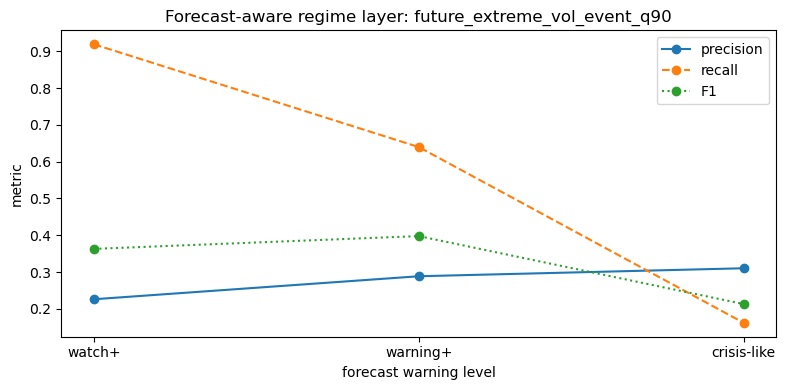

In [13]:
event_to_plot = 'future_extreme_vol_event_q90'
signal_order = ['forecast_watch_or_higher', 'forecast_warning_or_higher', 'forecast_crisis_like']
part = forecast_regime_eval[forecast_regime_eval['event'] == event_to_plot].set_index('signal').loc[signal_order].reset_index()
x = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, part['precision'], marker='o', label='precision')
ax.plot(x, part['recall'], marker='o', linestyle='--', label='recall')
ax.plot(x, part['f1'], marker='o', linestyle=':', label='F1')
ax.set_title(f'Forecast-aware regime layer: {event_to_plot}')
ax.set_xlabel('forecast warning level')
ax.set_ylabel('metric')
ax.set_xticks(x)
ax.set_xticklabels(['watch+', 'warning+', 'crisis-like'])
ax.legend()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_forecast_aware_regime_eval_q90.png', dpi=180)
plt.show()

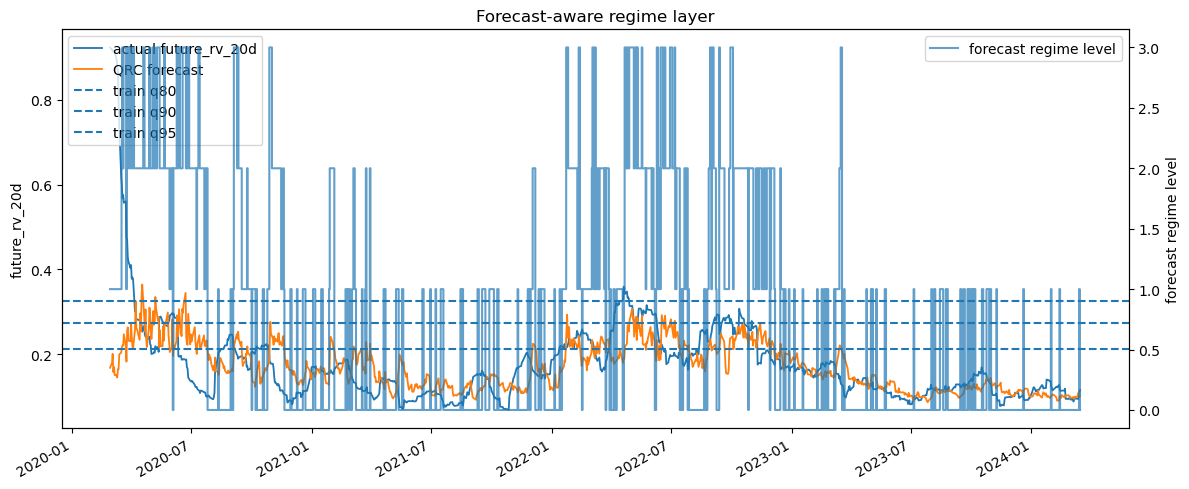

In [14]:
regime_to_level = {'normal': 0, 'watch': 1, 'warning': 2, 'crisis_like': 3}
forecast_layer['forecast_regime_level'] = forecast_layer['forecast_regime'].map(regime_to_level)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_layer['date'], forecast_layer['actual_future_rv_20d'], label='actual future_rv_20d', linewidth=1.3)
ax.plot(forecast_layer['date'], forecast_layer['qrc_pred_future_rv_20d'], label='QRC forecast', linewidth=1.3)
ax.axhline(thresholds['high_vol_q80'], linestyle='--', label='train q80')
ax.axhline(thresholds['extreme_vol_q90'], linestyle='--', label='train q90')
ax.axhline(thresholds['crisis_candidate_q95'], linestyle='--', label='train q95')
ax2 = ax.twinx()
ax2.step(forecast_layer['date'], forecast_layer['forecast_regime_level'], where='mid', label='forecast regime level', alpha=0.7)
ax.set_title('Forecast-aware regime layer')
ax.set_ylabel('future_rv_20d')
ax2.set_ylabel('forecast regime level')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_forecast_aware_regime_timeline.png', dpi=180)
plt.show()

## 9.6 Interpretation checkpoint

The QRC model provides a forecasted future-volatility substrate. The forecast-aware regime layer translates this into normal/watch/warning/crisis-like operational states by combining predicted volatility with contemporaneous market-stress confirmations. Because the final QRC underpredicts the most extreme COVID realized-volatility peak, crisis-like warnings should be interpreted as an application-layer high-severity stress descriptor rather than a standalone crisis classifier.